# 08 · 完整流程實戰

前七課的招式，這一課全部串起來，走一遍**真實的機器學習流程**：理解資料 → 切分 → 用 Pipeline 前處理 → 交叉驗證 → **GridSearch 調參** → 在測試集驗收 → 解讀結果。這就是你拿到一份新資料時該有的工作節奏。

## 學習目標

- 串起完整流程：資料 → Pipeline → 調參 → 評估
- 用 `GridSearchCV` 自動尋找最佳超參數
- 在被藏起來的測試集上做**最終、誠實的**驗收
- 解讀混淆矩陣與特徵重要性，產出結論

## 1. 認識資料

用乳癌診斷資料集：569 筆腫瘤切片，每筆 30 個數值特徵，要判斷**惡性 / 良性**。這是個典型的二元分類醫療問題。

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("資料形狀:", df.shape)
print("\n類別分布（0=惡性, 1=良性）:")
print(df["target"].value_counts())
df.head()

資料形狀: (569, 31)

類別分布（0=惡性, 1=良性）:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. 切分：先把測試集藏起來

第一步永遠是把測試集鎖進保險箱——接下來所有調參、驗證都只能用訓練集，測試集到最後一刻才開封。

In [2]:
from sklearn.model_selection import train_test_split

X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("訓練集:", X_train.shape, "  測試集:", X_test.shape)

訓練集: (455, 30)   測試集: (114, 30)


## 3. 組裝 Pipeline + GridSearch 調參

把「標準化 + 隨機森林」組成 Pipeline，再用 `GridSearchCV` 在訓練集上做交叉驗證、自動試各種超參數組合，挑出最好的。**整個調參過程完全不碰測試集**。

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42)),
])

# 要搜尋的超參數網格（語法：步驟名__參數名）
param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 5, 10],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("最佳參數:", grid.best_params_)
print(f"交叉驗證最佳 AUC: {grid.best_score_:.3f}")

最佳參數: {'clf__max_depth': 5, 'clf__n_estimators': 100}
交叉驗證最佳 AUC: 0.989


## 4. 最終驗收：開封測試集

調參全部結束，現在才第一次、也是唯一一次用測試集。`grid` 會自動用最佳參數的模型來預測。

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

測試集 AUC: 0.993



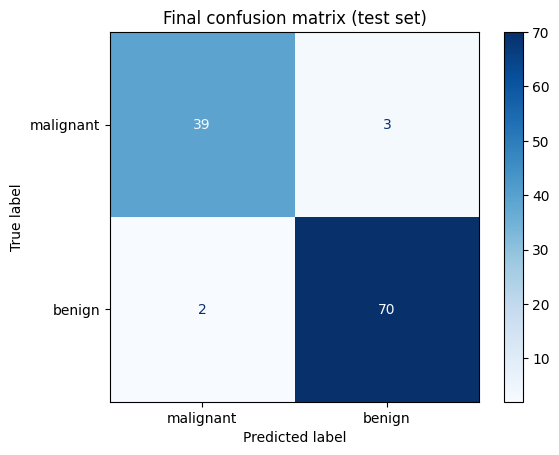

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

best = grid.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=data.target_names))
print(f"測試集 AUC: {roc_auc_score(y_test, y_proba):.3f}\n")

ConfusionMatrixDisplay.from_estimator(
    best, X_test, y_test, display_labels=data.target_names, cmap="Blues"
)
plt.title("Final confusion matrix (test set)")
plt.show()

> 在醫療場景，左下角那格——**把惡性誤判成良性**——是最危險的錯誤。看報告時 recall（惡性類別）要特別留意。

## 5. 解讀：哪些特徵在說話？

模型不是黑盒。掏出特徵重要性，看它根據什麼下判斷——這往往是交付成果時最有價值的洞察。

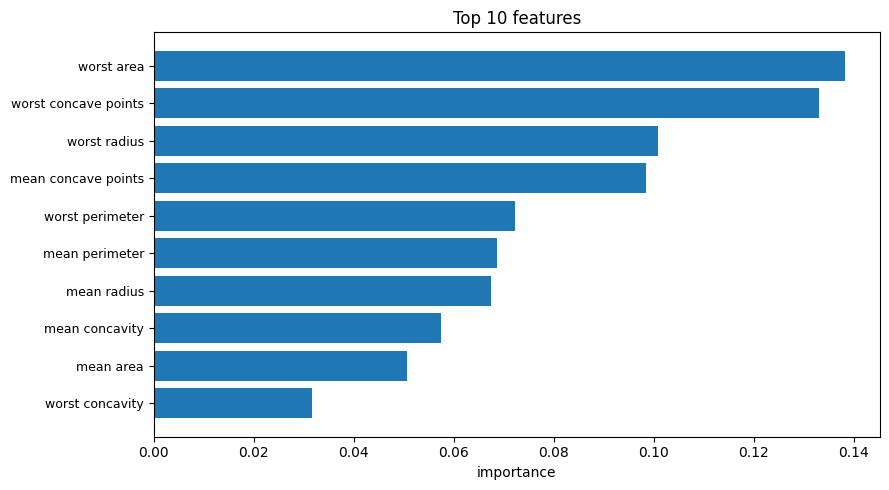

In [5]:
importances = best.named_steps["clf"].feature_importances_
order = np.argsort(importances)[::-1][:10]   # 取前 10 名

plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), importances[order][::-1])
plt.yticks(range(len(order)), np.array(data.feature_names)[order][::-1], fontsize=9)
plt.xlabel("importance"); plt.title("Top 10 features")
plt.tight_layout()
plt.show()

## 小結：機器學習的標準工作流程

恭喜你走完整個 scikit-learn 模組！把這條流程刻進肌肉記憶：

1. **理解資料** —— 形狀、類別分布、有沒有缺值
2. **切分** —— 測試集先藏好，絕不偷看
3. **Pipeline** —— 前處理 + 模型綁成一體，自動防資料洩漏
4. **交叉驗證 + 調參** —— 只在訓練集上用 `GridSearchCV` 找最佳設定
5. **最終驗收** —— 測試集只開封一次，看混淆矩陣 / report / AUC
6. **解讀** —— 用特徵重要性等工具產出洞察，而非只丟一個分數

## 練習（綜合）

1. 把 `RandomForestClassifier` 換成 `LogisticRegression`（記得 `max_iter` 調大），整條流程不動就能比較兩個模型。
2. 在 `param_grid` 多加一個超參數（如 `clf__min_samples_leaf`），看最佳組合與 AUC 有沒有提升。
3. 挑戰：用你自己的 CSV 資料，套用同一條六步流程。

這就是資料科學家每天在做的事——你已經有完整的骨架了。